# Model Explainability using SHAP

---

## Objective

Machine learning models often achieve high predictive performance but are difficult to interpret.

In industrial environments, explainability is essential to:

- understand why anomalies are detected
- identify critical sensors
- improve operator trust
- support predictive maintenance

This notebook applies SHAP (SHapley Additive exPlanations) to interpret the trained LightGBM model.

In [1]:
from pathlib import Path

import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import shap

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = PROJECT_ROOT / "models"

DATA_PATH = PROJECT_ROOT / "data" / "processed"

RESULT_PATH = PROJECT_ROOT / "results"

RESULT_PATH.mkdir(exist_ok=True)

In [3]:
model = joblib.load(
    MODEL_PATH / "best_model.pkl"
)

In [4]:
test = pd.read_csv(
    DATA_PATH / "test_data.csv"
)

X_test = test.drop(columns="Target")

y_test = test["Target"]

print(X_test.shape)

(288344, 51)


In [5]:
X_sample = X_test.sample(
    n=5000,
    random_state=42
)

In [6]:
explainer = shap.TreeExplainer(model)

In [7]:
shap_values = explainer.shap_values(X_sample)

In [8]:
print(type(shap_values))

print(np.array(shap_values).shape)

print(explainer.expected_value)

<class 'numpy.ndarray'>
(5000, 51, 2)
[0.49994123 0.50005877]


In [9]:
shap_attack = shap_values[:, :, 1]

base_value = explainer.expected_value[1]

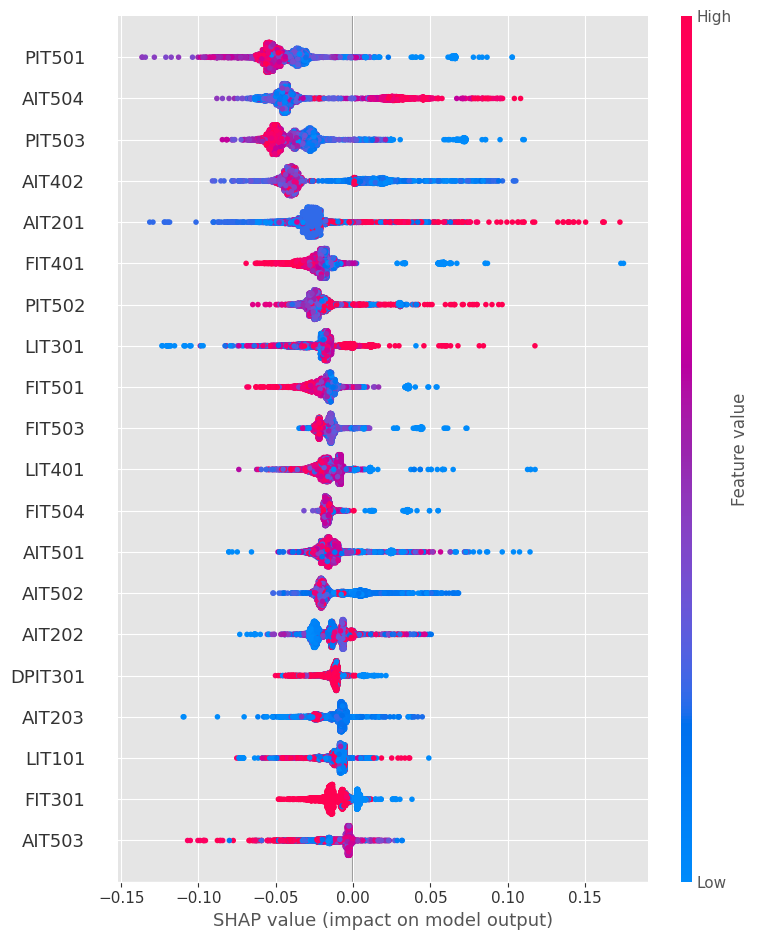

In [10]:
plt.figure()

shap.summary_plot(

    shap_attack,

    X_sample,

    show=False

)

plt.savefig(

    RESULT_PATH / "shap_summary.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [11]:
importance = pd.DataFrame({

    "Feature": X_sample.columns,

    "SHAP Importance": np.abs(

        shap_attack

    ).mean(axis=0)

})

importance = importance.sort_values(

    "SHAP Importance",

    ascending=False

).reset_index(drop=True)

importance.head(20)

,Feature,SHAP Importance
0,PIT501,0.047126
1,AIT504,0.042062
2,PIT503,0.040435
3,AIT402,0.033234
4,AIT201,0.029489
5,FIT401,0.023931
6,PIT502,0.023839
7,LIT301,0.021145
8,FIT501,0.020513
9,FIT503,0.017732


In [12]:
importance.to_csv(

    RESULT_PATH / "shap_feature_importance.csv",

    index=False

)

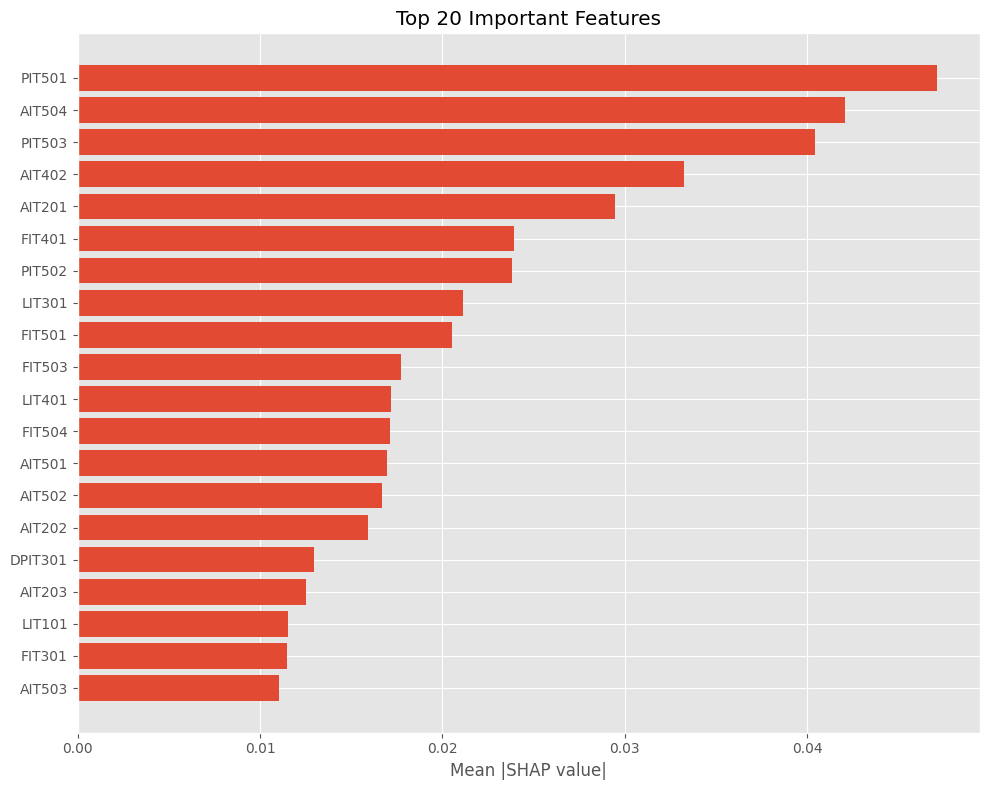

In [13]:
plt.figure(figsize=(10,8))

plt.barh(

    importance["Feature"][:20],

    importance["SHAP Importance"][:20]

)

plt.gca().invert_yaxis()

plt.xlabel("Mean |SHAP value|")

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"top20_shap.png",

    dpi=300

)

plt.show()

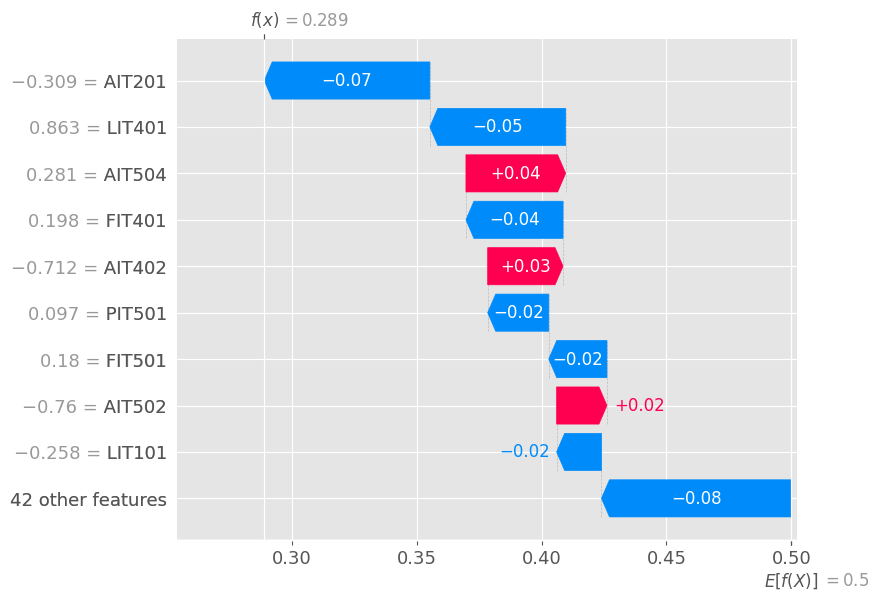

In [14]:
sample_id = 0

explanation = shap.Explanation(

    values=shap_attack[sample_id],

    base_values=base_value,

    data=X_sample.iloc[sample_id],

    feature_names=X_sample.columns

)

shap.plots.waterfall(

    explanation,

    show=False

)

plt.savefig(

    RESULT_PATH/"waterfall_plot.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

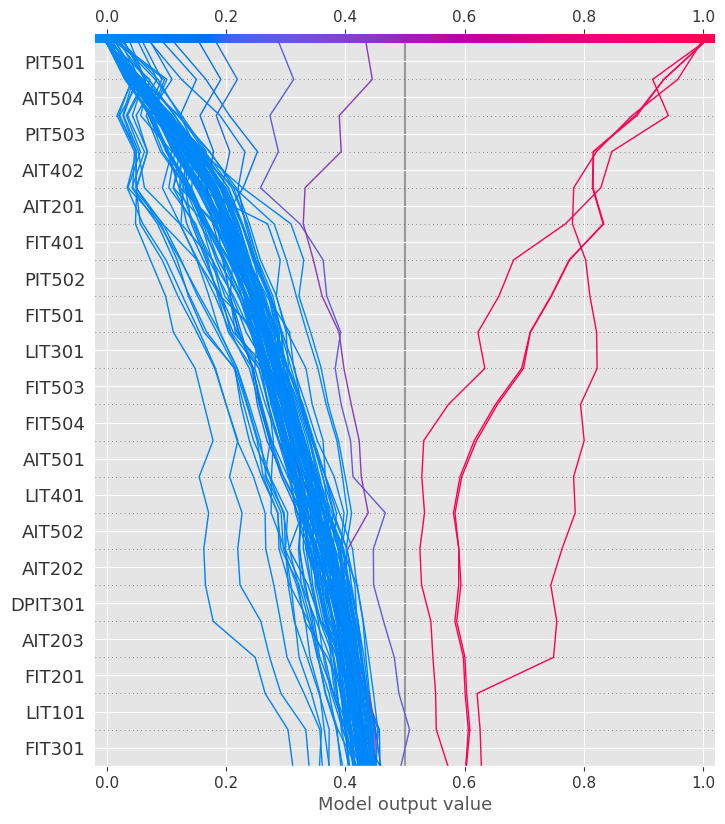

In [15]:
shap.decision_plot(

    base_value,

    shap_attack[:100],

    X_sample.iloc[:100],

    show=False

)

plt.savefig(

    RESULT_PATH/"decision_plot.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [16]:
top_feature = importance.iloc[0]["Feature"]

print(top_feature)

PIT501


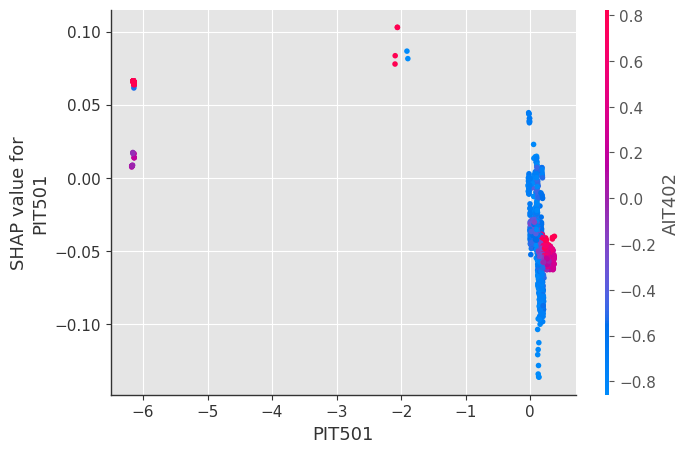

In [17]:
shap.dependence_plot(

    top_feature,

    shap_attack,

    X_sample,

    show=False

)

plt.savefig(

    RESULT_PATH/"dependence_plot.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [18]:
print("="*60)

print("Model Explainability Summary")

print("="*60)

print()

print(f"Most Important Feature : {importance.iloc[0]['Feature']}")

print()

print("Top Five Features:")

print()

print(importance.head())

Model Explainability Summary

Most Important Feature : PIT501

Top Five Features:

  Feature  SHAP Importance
0  PIT501         0.047126
1  AIT504         0.042062
2  PIT503         0.040435
3  AIT402         0.033234
4  AIT201         0.029489
